In [1]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from scipy.stats import linregress
from tools import *

## Plate 1

- A-C = P1
- D-F = P4
- G-H = ancestor

In [9]:
file_path1 = f'/Users/kellyhui/Downloads/RBG_data/6_20_26/KH_RBG_otr_062026_P_P6_14_anc.csv'
df1 = pd.read_csv(f'{file_path1}') 
df1 = clean_and_transpose(df1, 24, 122).dropna().transpose()
df1 = df1.reset_index()
df1.columns = ['Well', 'OD']
df1

,Well,OD
0,A1,0.3817
1,B1,0.4208
2,C1,0.4299
3,D1,0.4711
4,E1,0.4660
...,...,...
91,D12,0.4241
92,E12,0.4164
93,F12,0.3993
94,G12,0.2118


## Plate 2

- A-D = PF1
- E-G = PF2
- H = control

In [8]:
file_path2 = f'/Users/kellyhui/Downloads/RBG_data/6_20_26/KH_RBG_otr_062026_PF_P6_12.csv'
df2 = pd.read_csv(f'{file_path2}') 
df2 = clean_and_transpose(df2, 24, 122).dropna().transpose()
df2 = df2.reset_index()
df2.columns = ['Well', 'OD']
df2

,Well,OD
0,A1,0.4443
1,B1,0.4486
2,C1,0.3975
3,D1,0.4665
4,E1,0.4061
...,...,...
91,D12,0.4727
92,E12,0.3723
93,F12,0.3375
94,G12,0.4498


## Plate 3

- A-D = PF2
- E-G = PF1
- H = control

In [10]:
file_path3 = f'/Users/kellyhui/Downloads/RBG_data/6_20_26/KH_RBG_otr_062026_PF_P6_21.csv'
df3 = pd.read_csv(f'{file_path3}') 
df3 = clean_and_transpose(df3, 24, 122).dropna().transpose()
df3 = df3.reset_index()
df3.columns = ['Well', 'OD']
df3

,Well,OD
0,A1,0.4520
1,B1,0.3749
2,C1,0.4281
3,D1,0.3859
4,E1,0.4332
...,...,...
91,D12,0.3450
92,E12,0.4606
93,F12,0.3758
94,G12,0.4659


## Plate 4

- A-D = PF3
- E-G = PF4
- H = control

In [14]:
file_path4 = f'/Users/kellyhui/Downloads/RBG_data/6_20_26/KH_RBG_otr_062026_PF_P6_34.csv'
df4 = pd.read_csv(f'{file_path4}') 
df4 = clean_and_transpose(df4, 24, 122).dropna().transpose()
df4 = df4.reset_index()
df4.columns = ['Well', 'OD']
df4

,Well,OD
0,A1,0.4745
1,B1,0.4833
2,C1,0.4391
3,D1,0.4531
4,E1,0.4310
...,...,...
91,D12,0.3988
92,E12,0.3307
93,F12,0.3303
94,G12,0.3093


## Plate 5

- A-D = PF4
- E-G = PF3
- H = control

In [15]:
file_path5 = f'/Users/kellyhui/Downloads/RBG_data/6_20_26/KH_RBG_otr_062026_PF_P6_43.csv'
df5 = pd.read_csv(f'{file_path5}') 
df5 = clean_and_transpose(df5, 24, 122).dropna().transpose()
df5 = df5.reset_index()
df5.columns = ['Well', 'OD']
df5

,Well,OD
0,A1,0.3980
1,B1,0.3886
2,C1,0.3624
3,D1,0.3730
4,E1,0.4427
...,...,...
91,D12,0.3879
92,E12,0.5729
93,F12,0.5089
94,G12,0.3653


## Plate 6

- A-D = PF5
- E-G = PF6
- H = control

In [16]:
file_path6 = f'/Users/kellyhui/Downloads/RBG_data/6_20_26/KH_RBG_otr_062026_PF_P6_56.csv'
df6 = pd.read_csv(f'{file_path6}') 
df6 = clean_and_transpose(df6, 24, 122).dropna().transpose()
df6 = df6.reset_index()
df6.columns = ['Well', 'OD']
df6

,Well,OD
0,A1,0.4615
1,B1,0.3617
2,C1,0.4632
3,D1,0.4577
4,E1,0.3499
...,...,...
91,D12,0.4472
92,E12,0.4136
93,F12,0.3843
94,G12,0.3652


## Plate 7
- A-D = PF6
- E-G = PF5
- H = control

In [18]:
file_path7 = f'/Users/kellyhui/Downloads/RBG_data/6_20_26/KH_RBG_otr_062026_PF_P6_65.csv'
df7 = pd.read_csv(f'{file_path7}') 
df7 = clean_and_transpose(df7, 24, 122).dropna().transpose()
df7 = df7.reset_index()
df7.columns = ['Well', 'OD']
df7

,Well,OD
0,A1,0.3447
1,B1,0.3489
2,C1,0.3359
3,D1,0.3472
4,E1,0.3041
...,...,...
91,D12,0.3870
92,E12,0.3091
93,F12,0.3331
94,G12,0.4382


## Assign Phage Dose

In [45]:
dataframes = [df1, df2, df3, df4, df5, df6, df7]

def tidy_plate(df, plate_num):

    # Extract BioRep and column number
    df['BioRep'] = df['Well'].str[0]
    df['Col'] = df['Well'].str[1:].astype(int)

    # Map column number to dose
    def col_to_dose(col):
        if col in [1,2,3]:
            return 0
        elif col in [4,5,6]:
            return 1e4
        elif col in [7,8,9]:
            return 1e6
        elif col in [10,11,12]:
            return 1e8
        else:
            return np.nan

    df['Dose'] = df['Col'].apply(col_to_dose)
    df = df.sort_values(by=['BioRep', 'Dose', 'Col']).reset_index(drop=True)

    df = df[df['BioRep'] != 'H']

    df['Plate'] = plate_num

    return df[['Plate','BioRep','Dose','Col','OD']]

tbl_arr = [tidy_plate(dataframes[i], i+1) for i in range(7)]

# Combine plates into proper dataframes

### PF1

In [35]:
PF1_1 = tbl_arr[1][tbl_arr[1]['BioRep'].isin(['A', 'B', 'C', 'D'])]
PF1_2 = tbl_arr[2][tbl_arr[2]['BioRep'].isin(['E', 'F', 'G', 'H'])]

PF1 = pd.concat([PF1_1, PF1_2], ignore_index=True)

### PF2

In [38]:
PF2_1 = tbl_arr[2][tbl_arr[2]['BioRep'].isin(['A', 'B', 'C', 'D'])]
PF2_2 = tbl_arr[1][tbl_arr[1]['BioRep'].isin(['E', 'F', 'G', 'H'])]

PF2 = pd.concat([PF2_1, PF2_2], ignore_index=True)

### PF3

In [39]:
PF3_1 = tbl_arr[3][tbl_arr[3]['BioRep'].isin(['A', 'B', 'C', 'D'])]
PF3_2 = tbl_arr[4][tbl_arr[4]['BioRep'].isin(['E', 'F', 'G', 'H'])]

PF3 = pd.concat([PF3_1, PF3_2], ignore_index=True)
PF3

,Plate,BioRep,Dose,Col,OD
0,4,A,0.0,1,0.4745
1,4,A,0.0,2,0.3851
2,4,A,0.0,3,0.3590
3,4,A,10000.0,4,0.4249
4,4,A,10000.0,5,0.3846
...,...,...,...,...,...
79,5,G,1000000.0,8,0.3860
80,5,G,1000000.0,9,0.3778
81,5,G,100000000.0,10,0.4026
82,5,G,100000000.0,11,0.4034


### PF4

In [41]:
PF4_1 = tbl_arr[4][tbl_arr[4]['BioRep'].isin(['A', 'B', 'C', 'D'])]
PF4_2 = tbl_arr[3][tbl_arr[3]['BioRep'].isin(['E', 'F', 'G', 'H'])]

PF4 = pd.concat([PF4_1, PF4_2], ignore_index=True)
PF4

,Plate,BioRep,Dose,Col,OD
0,5,A,0.0,1,0.3980
1,5,A,0.0,2,0.3445
2,5,A,0.0,3,0.3377
3,5,A,10000.0,4,0.3375
4,5,A,10000.0,5,0.3235
...,...,...,...,...,...
79,4,G,1000000.0,8,0.2981
80,4,G,1000000.0,9,0.2840
81,4,G,100000000.0,10,0.3006
82,4,G,100000000.0,11,0.2938


### PF5

In [48]:
PF5_1 = tbl_arr[5][tbl_arr[5]['BioRep'].isin(['A', 'B', 'C', 'D'])]
PF5_2 = tbl_arr[6][tbl_arr[6]['BioRep'].isin(['E', 'F', 'G', 'H'])]

PF5 = pd.concat([PF5_1, PF5_2], ignore_index=True)
PF5

,Plate,BioRep,Dose,Col,OD
0,6,A,0.0,1,0.4615
1,6,A,0.0,2,0.4692
2,6,A,0.0,3,0.4926
3,6,A,10000.0,4,0.4977
4,6,A,10000.0,5,0.4949
...,...,...,...,...,...
79,7,G,1000000.0,8,0.5398
80,7,G,1000000.0,9,0.5148
81,7,G,100000000.0,10,0.5028
82,7,G,100000000.0,11,0.4954


### PF6

In [49]:
PF6_1 = tbl_arr[6][tbl_arr[6]['BioRep'].isin(['A', 'B', 'C', 'D'])]
PF6_2 = tbl_arr[5][tbl_arr[5]['BioRep'].isin(['E', 'F', 'G', 'H'])]

PF6 = pd.concat([PF6_1, PF6_2], ignore_index=True)
PF6

,Plate,BioRep,Dose,Col,OD
0,7,A,0.0,1,0.3447
1,7,A,0.0,2,0.3334
2,7,A,0.0,3,0.3266
3,7,A,10000.0,4,0.3445
4,7,A,10000.0,5,0.3363
...,...,...,...,...,...
79,6,G,1000000.0,8,0.3629
80,6,G,1000000.0,9,0.3584
81,6,G,100000000.0,10,0.3732
82,6,G,100000000.0,11,0.3458


In [51]:
PF_dataframes = [PF1, PF2, PF3, PF4, PF5, PF6]

# groupings

In [54]:
#group plate, biol rep, and dose
bio_rep_mean = [tbl.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() for tbl in PF_dataframes]

In [55]:
plate_results = []

for df in tbl_arr:
    df = df.copy()

    # log transform (handle 0)
    df["Dose_log"] = np.log10(df["Dose"] + 0.01)

    x = df["Dose_log"].values
    y = df["OD"].values

    if len(x) < 2:
        continue

    slope, intercept, r_value, p_value, _ = linregress(x, y)

    plate_results.append({
        "Plate": df["Plate"].iloc[0],
        "R2": r_value**2,
        "p_value": p_value,
        "slope": slope
    })

plate_table = pd.DataFrame(plate_results)
plate_table 

,Plate,R2,p_value,slope
0,1,0.248460,0.000001,-0.011789
1,2,0.025922,0.143444,0.004619
2,3,0.048461,0.044206,0.005748
3,4,0.027361,0.132666,-0.001933
4,5,0.082479,0.008079,0.003297
5,6,0.010870,0.345273,0.001925
6,7,0.000539,0.833986,0.000440


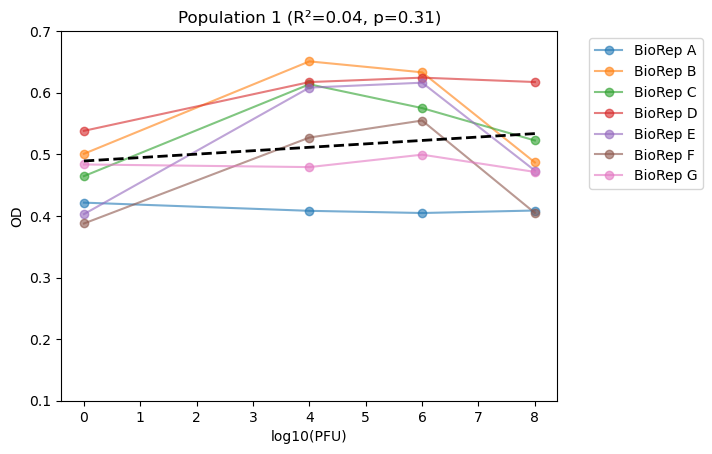

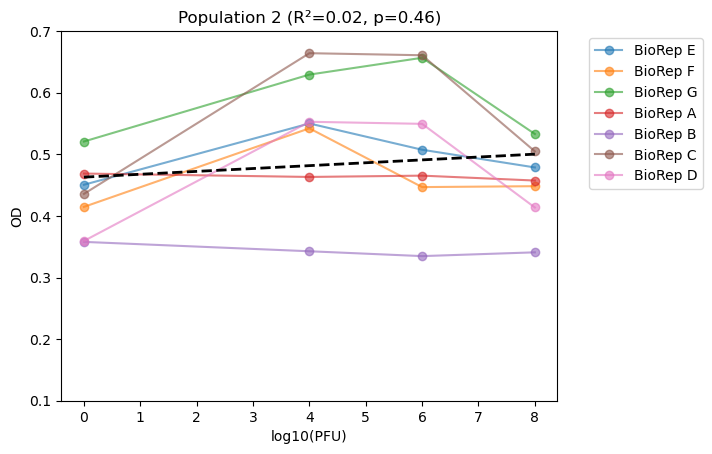

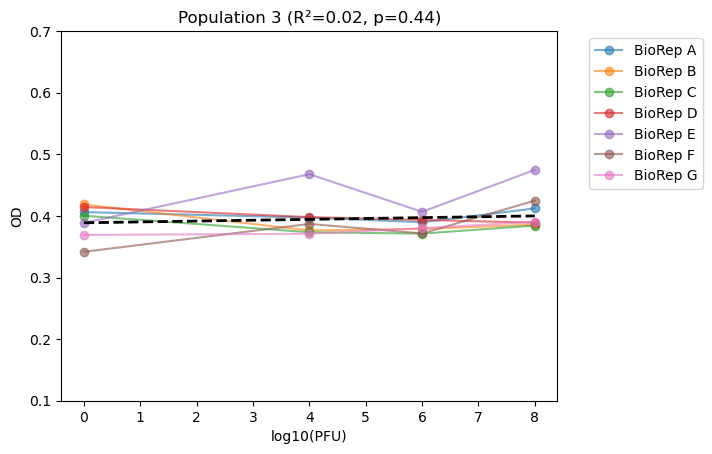

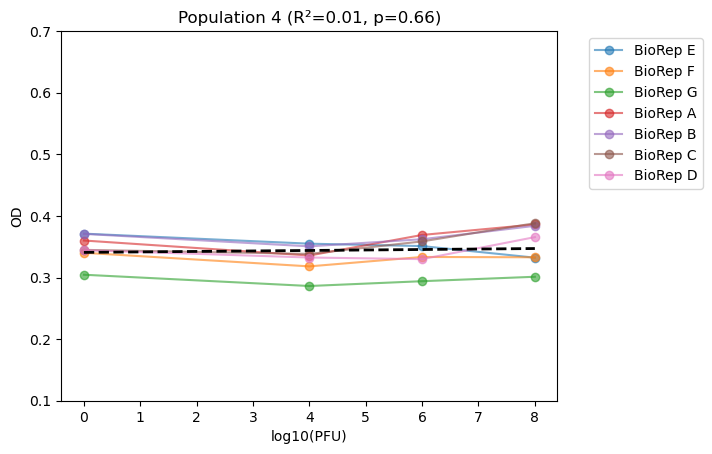

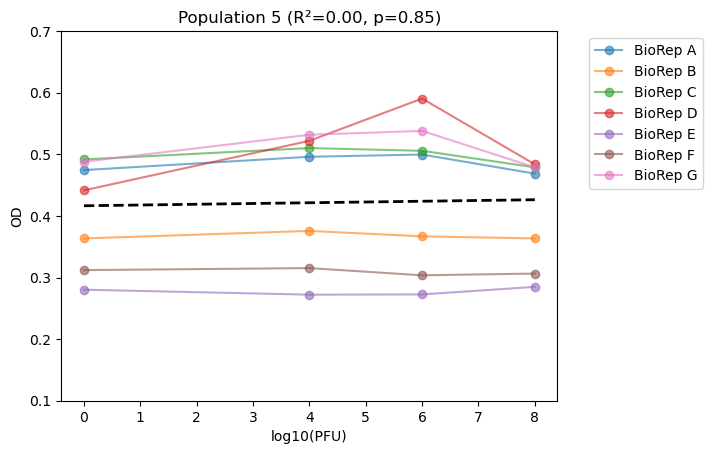

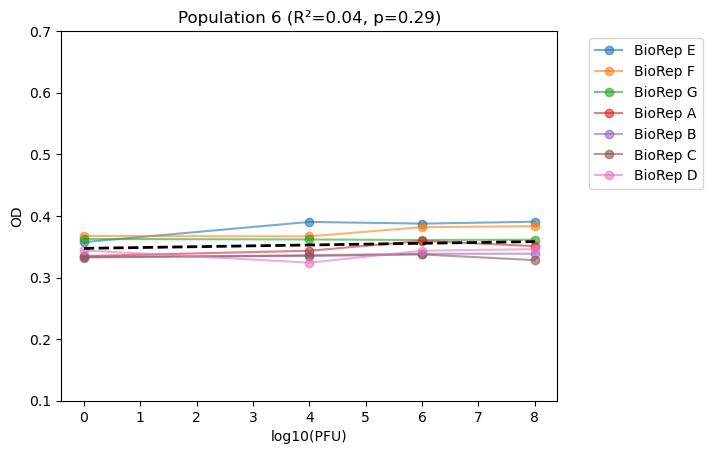

In [58]:
for i, df in enumerate(bio_rep_mean):
    plt.figure()

    df = df.copy()
    df['Dose_plot'] = df['Dose'].apply(lambda x: 0 if x == 0 else np.log10(x))

    x_all = df['Dose_plot'].values
    y_all = df['OD'].values

    slope, intercept, r_value, p_value, _ = linregress(x_all, y_all)
    r2 = r_value**2

    #plot each BioRep
    for bio in df['BioRep'].unique():
        bio_df = df[df['BioRep'] == bio]

        plt.plot(
            bio_df['Dose_plot'],
            bio_df['OD'],
            marker='o',
            alpha=0.6,
            label=f'BioRep {bio}'
        )


    #plot the regression line
    x_line = np.linspace(min(x_all), max(x_all), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linestyle='--', linewidth=2, color='black')

    # --- labels ---
    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(
        f'Population {i+1} (R²={r2:.2f}, p={p_value:.2g})'
    )

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.1, 0.7)

    plt.show()